# Lab 4: Data Visualization and Interpretation Using Matplotlib-II

## Imports

In [22]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

## Loading the dataset

In [2]:
df = pd.read_csv("datasets/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Tasks

### 1. Area Chart

o Create an area chart showing the average petal length for each species.  
o Title: "Average Petal Length by Species"  
o X-axis: Species  
o Y-axis: Average Petal Length (cm)  
o Add legend and gridlines (major and minor).  
o Set the legend position to the bottom-right corner.  
o Add a legend title "Species" and set the legend font size to 12.  

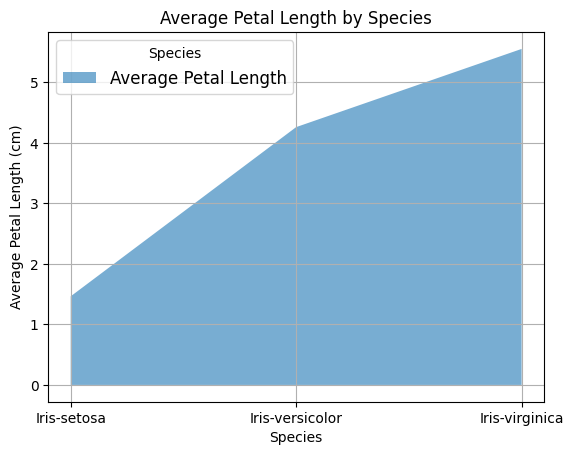

In [8]:
apl = df.groupby("Species")["PetalLengthCm"].mean()

plt.figure()
plt.fill_between(apl.index, apl.values, alpha=0.6, label="Average Petal Length")
plt.title("Average Petal Length by Species")
plt.xlabel("Species")
plt.ylabel("Average Petal Length (cm)")
plt.grid(True, which="both")
plt.legend(title="Species", fontsize=12, loc="upper left")
plt.savefig("plots/lab4/area_chart.png")
plt.show()

### 2. Bubble Chart

o X-axis: Sepal Length  
o Y-axis: Sepal Width  
o Bubble size: Petal Length  
o Bubble color: Species  
o Title: "Iris Flower Features"  

In [13]:
df["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

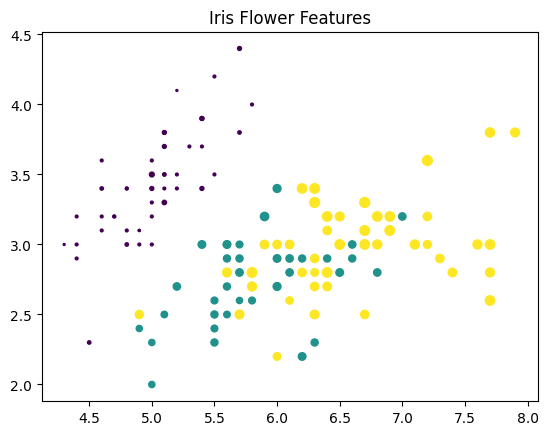

In [21]:
x = df["SepalLengthCm"]
y = df["SepalWidthCm"]
bubble_size = df["PetalWidthCm"] * 20
bubble_color = df["Species"].astype("category").cat.codes

plt.figure()
scatter = plt.scatter(x, y, s=bubble_size, c=bubble_color)

plt.title("Iris Flower Features")
plt.savefig("plots/lab4/bubble_chart.png")
plt.show()

### 3. Heat Map

o Create a correlation heatmap for all numeric features.  
o Title: "Heatmap of Iris features"  

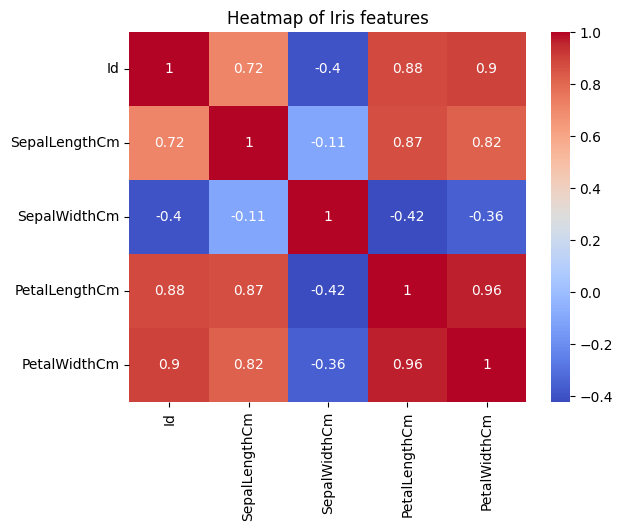

In [27]:
import seaborn as sns
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Heatmap of Iris features")
plt.savefig("plots/lab4/heatmap.png")
plt.show()

### 4. Box Plot

o Create box plots for petal length by species.  
o Title: "Petal Length Distribution by Species"  
o Create box plots showing the distribution of petal length for each species.  
o Clearly represent the median, first quartile (Q1), third quartile (Q3), and the interquartile  
range (IQR).  
o Display outliers using distinct marker symbols for easy identification.  
o Use different colors for each species to ensure clear visual distinction.  

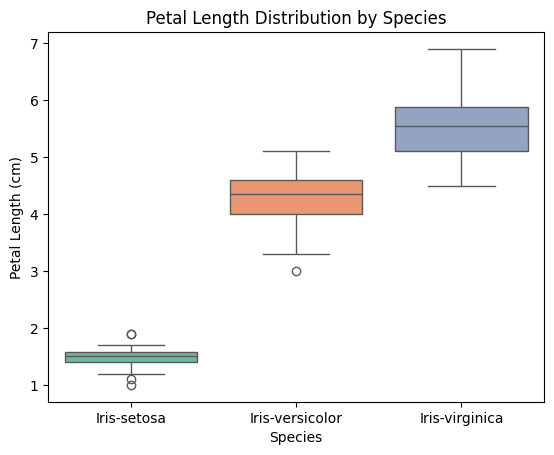

In [55]:
sns.boxplot(
    x="Species", y="PetalLengthCm", data=df, 
    hue="Species", palette="Set2",
    flierprops=dict(marker="o", markersize=6)
)
plt.title("Petal Length Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Petal Length (cm)")

plt.savefig("plots/lab4/box_plot.png")
plt.show()

### 5. Violin Plot

o Create violin plots for petal width across species.  
o Title: "Petal Width Distribution by Species"  

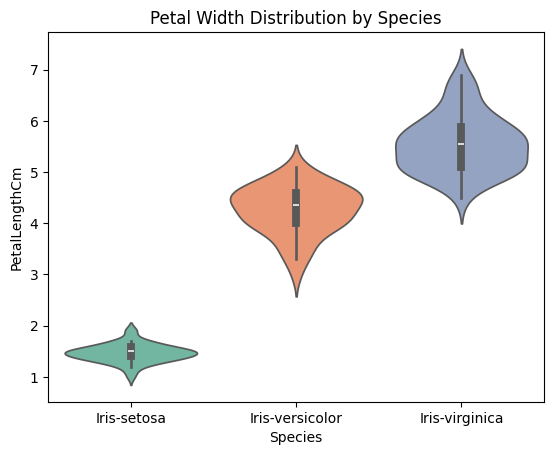

In [56]:
sns .violinplot(x="Species", y="PetalLengthCm", data=df, hue="Species", palette="Set2")
plt.title("Petal Width Distribution by Species")
plt.savefig("plots/lab4/violin_plot.png")
plt.show()

### 6. Pair Plot

o Create pairwise scatter plots between all numeric features.  
o Create pairwise scatter plots between all numeric features of the Iris dataset: Sepal
Length, Sepal Width, Petal Length and Petal Width.  
o Display feature-to-feature relationships across all possible combinations.  
o Use a consistent axis scale for all subplots to ensure fair visual comparison. Apply
uniform marker style and size for visual consistency.  
o Use different colors for different species to enable class-wise visual separation.  
o Maintain color consistency for each species across all subplots  

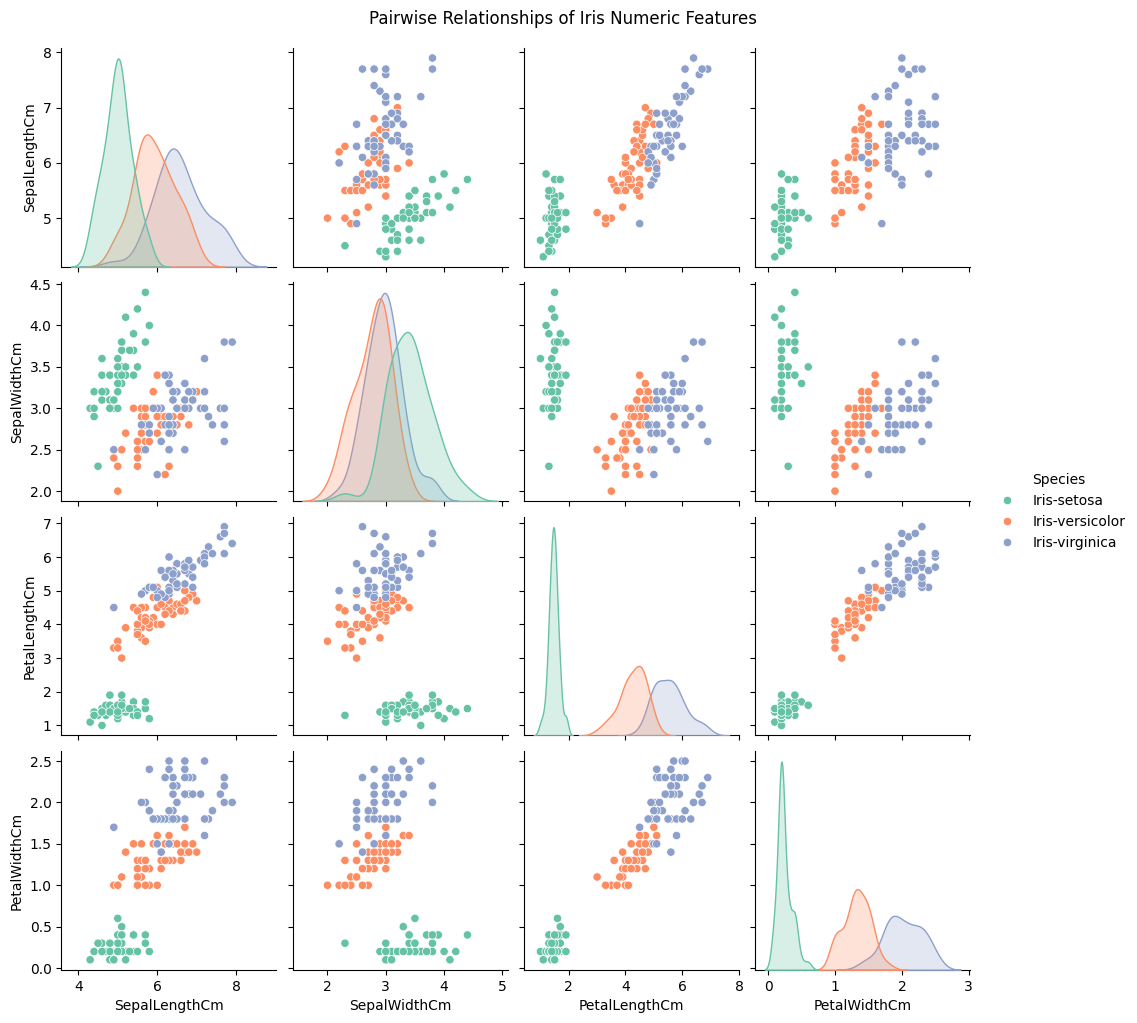

In [74]:
sns.pairplot(
    data=df, vars=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"],
    hue="Species", palette="Set2", markers="o"
)
plt.suptitle("Pairwise Relationships of Iris Numeric Features", y=1.02)
plt.savefig("plots/lab4/pairplot.png")
plt.show()